In [2]:
#core libraries
import pandas as pd
import numpy as np
#visualization for later in EDA
import matplotlib.pyplot as plt
import seaborn as sns
#optional display settings
pd.set_option('display.max_columns', None)
sns.set(style= "whitegrid")

In [3]:
df = pd.read_csv("../data/raw/PS_20174392719_1491204439457_log.csv")
df.head()


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
df.shape
df.info()

df['isFraud'].value_counts(normalize=True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


isFraud
0    0.998709
1    0.001291
Name: proportion, dtype: float64

In [5]:
# Compare fraud by payment type
fraud_by_type = df.groupby("type")["isFraud"].mean().sort_values(ascending=False)
print(fraud_by_type)

# Compare average amount by payment type
amount_by_type = df.groupby("type")["amount"].mean().sort_values(ascending=False)
print(amount_by_type)

# Compare average amount for fraud vs non-fraud
amount_by_fraud = df.groupby("isFraud")["amount"].mean()
print(amount_by_fraud)

type
TRANSFER    0.007688
CASH_OUT    0.001840
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64
type
TRANSFER    910647.009645
CASH_OUT    176273.964346
CASH_IN     168920.242004
PAYMENT      13057.604660
DEBIT         5483.665314
Name: amount, dtype: float64
isFraud
0    1.781970e+05
1    1.467967e+06
Name: amount, dtype: float64


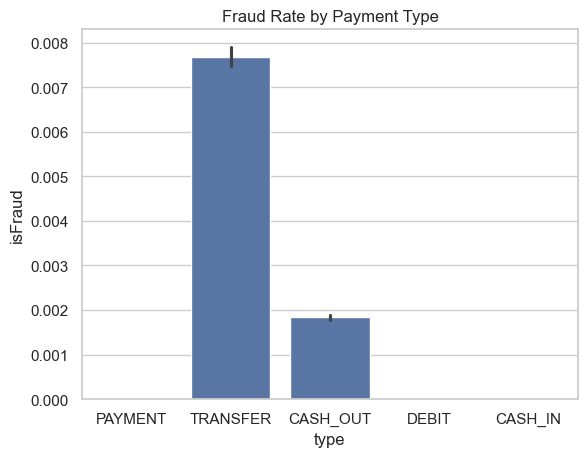

In [6]:
sns.barplot(data=df, x="type", y="isFraud")
plt.title("Fraud Rate by Payment Type")
plt.show()

Fraud shows up most often in TRANSFER and CASH_OUT transactions. TRANSFER has the highest fraud rate, while other forms of payment (besides CASH_OUT) show no fraud.

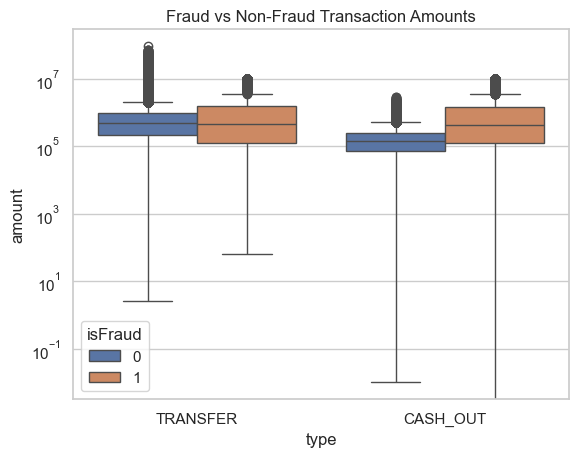

In [7]:
sns.boxplot(data=df[df["type"].isin(["TRANSFER", "CASH_OUT"])],
            x="type", y="amount", hue="isFraud")
plt.yscale("log")
plt.title("Fraud vs Non-Fraud Transaction Amounts")
plt.show()

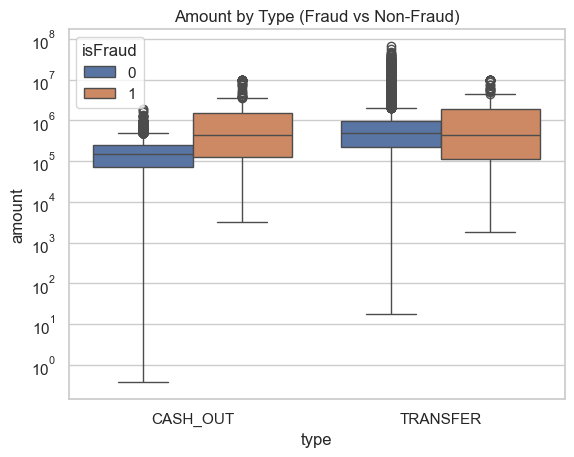

In [8]:
subset = df[df["type"].isin(["TRANSFER", "CASH_OUT"])].sample(150_000)

sns.boxplot(data=subset, x="type", y="amount", hue="isFraud")
plt.yscale("log")
plt.title("Amount by Type (Fraud vs Non-Fraud)")
plt.show()

Fraud tends to occur more often at higher transaction amounts, but amount alone does not fully seperate fraud from non-fraud. There is also significant overlap with non fraud transactions.

In [9]:
df.groupby('isFraud')[[
    'oldbalanceOrg',
    'newbalanceOrig',
    'oldbalanceDest',
    'newbalanceDest'
]].mean()

,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest
isFraud,,,,
0,8.328287e+05,855970.228109,1.101421e+06,1.224926e+06
1,1.649668e+06,192392.631836,5.442496e+05,1.279708e+06


In [5]:
# Check sender balance math
df["orig_balance_error"] = df["oldbalanceOrg"] - df["amount"] - df["newbalanceOrig"]

# Check receiver balance math
df["dest_balance_error"] = df["oldbalanceDest"] + df["amount"] - df["newbalanceDest"]

# Compare average error for fraud vs non-fraud
print(df.groupby("isFraud")[["orig_balance_error", "dest_balance_error"]].mean())

# Count how often the balance math is not exact
df["orig_math_broken"] = df["orig_balance_error"] != 0
df["dest_math_broken"] = df["dest_balance_error"] != 0

print(df.groupby("isFraud")[["orig_math_broken", "dest_math_broken"]].mean())

         orig_balance_error  dest_balance_error
isFraud                                        
0            -201338.558109        54692.231734
1             -10692.325265       732509.301069
         orig_math_broken  dest_math_broken
isFraud                                    
0                0.851987          0.744578
1                0.015463          0.648241


### Insight: Balance Consistency and Fraud Behavior

Fraudulent transactions show distinct balance behavior compared to non-fraudulent transactions. While non-fraud transactions frequently show inconsistencies in both origin and destination balances. Fraudulent transactions tend to maintain more consistent origin account behavior but introduce significantly larger inconsistencies in destination account balances. This suggests that fraudulent activity involves controlled withdrawal from the source account followed by irregular or abnormal changes in the receiving account.

<Axes: xlabel='isFraud', ylabel='dest_balance_error'>

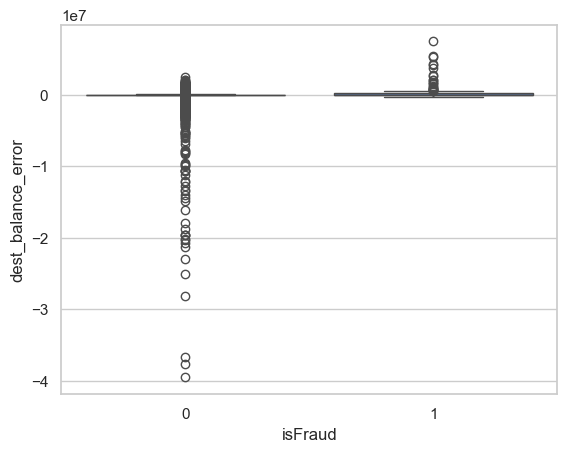

In [7]:
sns.boxplot(data=df.sample(100000), x='isFraud', y='dest_balance_error')

In [8]:
pd.crosstab(df['dest_math_broken'], df['isFraud'], normalize='index')

isFraud,0,1
dest_math_broken,,
False,0.998223,0.001777
True,0.998876,0.001124


Fraudulent transactions tend to produce larger changes or inconsistencies in destination balances.

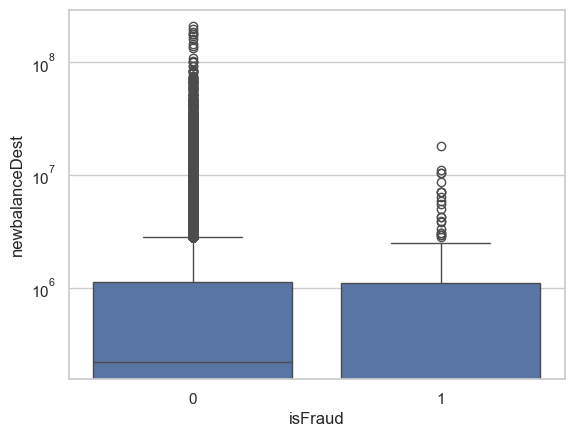

In [9]:
sns.boxplot(data=df.sample(100000), x='isFraud', y='newbalanceDest')
plt.yscale('log')

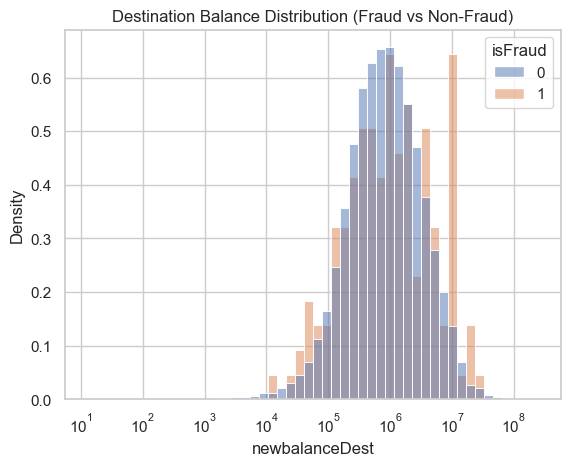

In [17]:
sns.histplot(
    data=df[df['type'].isin(['TRANSFER', 'CASH_OUT'])].sample(100000),
    x='newbalanceDest',
    hue='isFraud',
    log_scale=True,
    stat='density',
    common_norm=False,
    bins=50
)
plt.title("Destination Balance Distribution (Fraud vs Non-Fraud)")
plt.show()

In [18]:
df = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])].copy()
pd.qcut(df['newbalanceDest'], q=5, duplicates='drop')

2                  (-0.001, 261641.32]
3                  (-0.001, 261641.32]
15                 (-0.001, 261641.32]
19                 (-0.001, 261641.32]
24         (2674426.574, 356179278.92]
                      ...             
6362615        (261641.32, 579163.954]
6362616            (-0.001, 261641.32]
6362617    (2674426.574, 356179278.92]
6362618            (-0.001, 261641.32]
6362619    (2674426.574, 356179278.92]
Name: newbalanceDest, Length: 2770409, dtype: category
Categories (5, interval[float64, right]): [(-0.001, 261641.32] < (261641.32, 579163.954] < (579163.954, 1182581.906] < (1182581.906, 2674426.574] < (2674426.574, 356179278.92]]

In [19]:
df.groupby('isFraud')[['orig_balance_error', 'dest_balance_error']].median()

,orig_balance_error,dest_balance_error
isFraud,,
0,-144200.825,0.00
1,0.000,2231.46


In [20]:
df['dest_error_flag'] = (df['dest_balance_error'].abs() > 1)

df.groupby('dest_error_flag')['isFraud'].mean()

dest_error_flag
False    0.001590
True     0.015705
Name: isFraud, dtype: float64

In [21]:
df.groupby(['type', 'dest_error_flag'])['isFraud'].mean()

type      dest_error_flag
CASH_OUT  False              0.001962
          True               0.000671
TRANSFER  False              0.000006
          True               0.070510
Name: isFraud, dtype: float64

In [22]:
numeric_cols = [
    'amount',
    'oldbalanceOrg',
    'newbalanceOrig',
    'oldbalanceDest',
    'newbalanceDest',
    'orig_balance_error',
    'dest_balance_error',
    'isFraud'
]

corr = df[numeric_cols].corr()

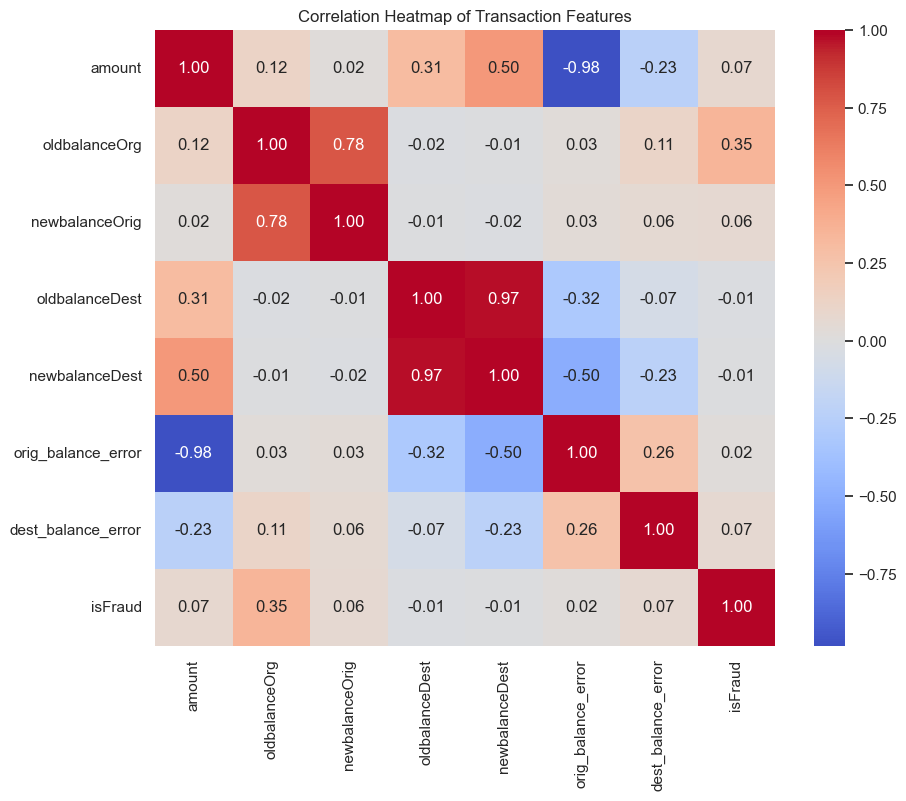

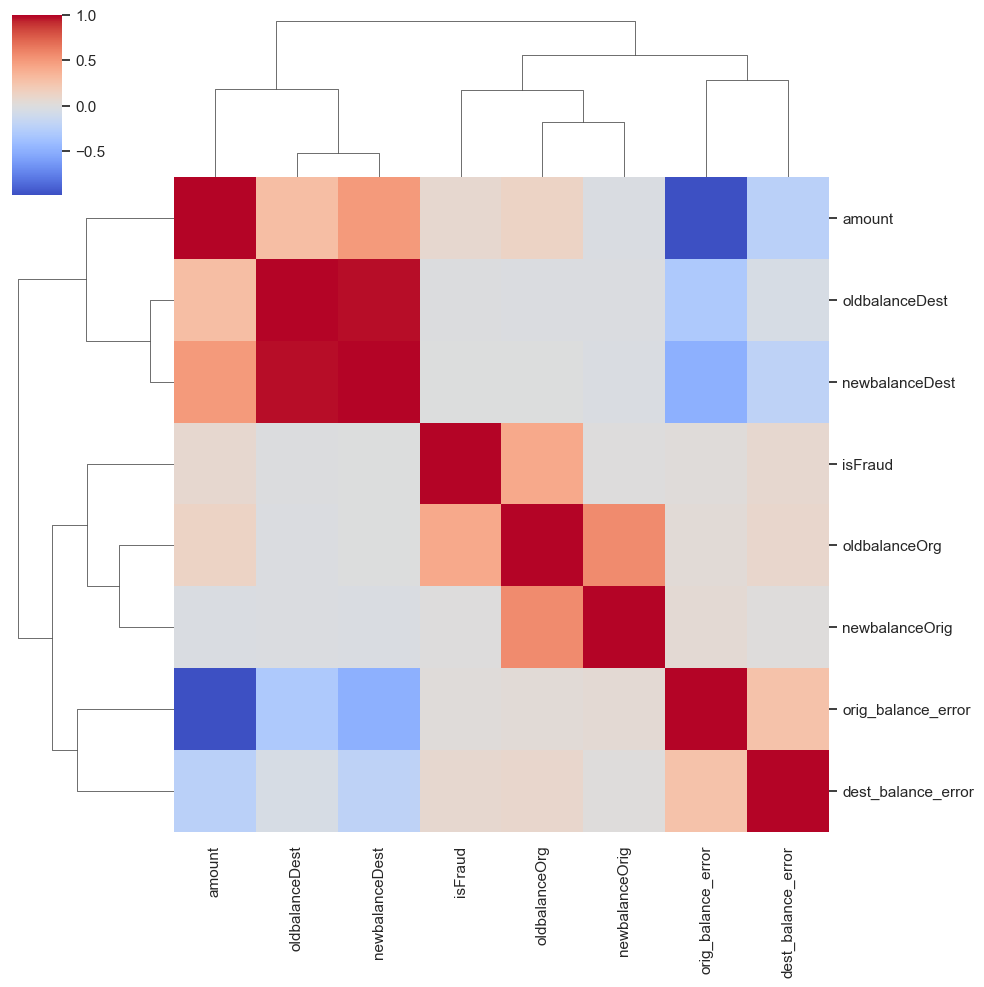

In [24]:


plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Transaction Features")
plt.show()
subset = df.sample(100000)  # for performance
sns.clustermap(subset[numeric_cols].corr(), cmap="coolwarm", center=0)